# AOS Nightly Plots

**Author:** Aaron Roodman  
**Date Created:** 2026-03-14  
**Last Modified:** 2026-03-14  
**Status:** Draft | In Progress | Complete  
**Keywords:** AOS, Image Quality

## Description

Plots of AOS FWHM or Zernike Deviations from multiple nights 

Key functionality:
1. Study AOS performance
2. Study Zernike and Vmodes

**Output:** Plots of AOS FWHM

**Based on:** Uses output from nightly_tablemaker from multiple nights

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-03-14 | Aaron Roodman | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Analysis](#analysis)
6. [Results & Plots](#results)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

day_obs_list = [20260311,20260312,20260313]              # Observation dates
# butler_repo = '/repo/main'      # Butler repository path
# collections = ['LSSTComCam/raw/all']  # Butler collections
# output_file = output              # Output file path (None = no file output)

<a id='setup'></a>
## Setup & Imports

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.stats import mad_std

# from astropy import units as u
# from astropy.coordinates import SkyCoord
# import astropy.io.fits as fits

# LSST imports (available on RSP)
# import lsst.daf.butler as dafButler
# import lsst.afw.display as afwDisplay

# from tqdm.notebook import tqdm

# Add repo root to path for common imports
sys.path.insert(0, str(Path.cwd().parent))
from common.utils import setup_plotting

setup_plotting()

<a id='functions'></a>
## Helper Functions

In [3]:
def clipped_scatter(ax, x, y, label=None, s=1, pct_low=2, pct_high=98, stats_box=True):
    """Scatter plot clipped to percentile range, with outliers plotted on the edges.
    Optionally draws a stats box with mean, RMS and MAD."""
    y = np.array(y, dtype=float)
    yfinite = y[np.isfinite(y)]

    if len(yfinite) == 0:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes,
                ha='center', va='center', color='red')
        return

    ylo = np.nanpercentile(y, pct_low)
    yhi = np.nanpercentile(y, pct_high)
    y_clipped = np.clip(y, ylo, yhi)

    mean = np.mean(yfinite)
    rms = np.std(yfinite)
    mad = mad_std(yfinite)

    ax.scatter(x, y_clipped, s=s, label=label, zorder=3)
    ax.set_ylim(ylo, yhi)
    if label is not None:
        ax.legend()

    if stats_box:
        stats_text = f'Mean = {mean:.3g}\nRMS  = {rms:.3g}\nMAD  = {mad:.3g}'
        ax.text(0.02, 0.97, stats_text, transform=ax.transAxes,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

In [36]:
labels_50dof = [
    'M2_dz', 'M2_dx', 'M2_dy', 'M2_rx', 'M2_ry',
    'Cam_dz', 'Cam_dx', 'Cam_dy', 'Cam_rx', 'Cam_ry',
    'B1_1', 'B1_2', 'B1_3', 'B1_4', 'B1_5',
    'B1_6', 'B1_7', 'B1_8', 'B1_9', 'B1_10',
    'B1_11', 'B1_12', 'B1_13', 'B1_14', 'B1_15',
    'B1_16', 'B1_17', 'B1_18', 'B1_19', 'B1_20',
    'B2_1', 'B2_2', 'B2_3', 'B2_4', 'B2_5',
    'B2_6', 'B2_7', 'B2_8', 'B2_9', 'B2_10',
    'B2_11', 'B2_12', 'B2_13', 'B2_14', 'B2_15',
    'B2_16', 'B2_17', 'B2_18', 'B2_19', 'B2_20',
]
labels_22dof = [
    'M2_dz', 'M2_dx', 'M2_dy', 'M2_rx', 'M2_ry',
    'Cam_dz', 'Cam_dx', 'Cam_dy', 'Cam_rx', 'Cam_ry',
    'B1_1', 'B1_2', 'B1_3', 'B1_4', 'B1_5',
    'B1_6', 'B1_7', 
    'B2_1', 'B2_2', 'B2_3', 'B2_4', 'B2_5',
]

def _extract_element(x, iDof):
    """Safely extract element iDof from a numpy array, returning NaN otherwise."""
    return x[iDof] if isinstance(x, np.ndarray) else float('nan')

def get_dof(table, name):
    """Extract a DOF time series from dof_state by name."""
    iDof = labels_50dof.index(name)
    return table['dof_state'].apply(lambda x: _extract_element(x, iDof))

def get_lut(table, name):
    """Extract a LUT time series from lut_state by name."""
    iDof = labels_50dof.index(name)
    return table['lut_state'].apply(lambda x: _extract_element(x, iDof))


<a id='data'></a>
## Data Access

In [5]:
tables = {}
for day_obs in day_obs_list:
    tables[day_obs] = pd.read_parquet('output/nightly_aos_table_%d.parquet'  % (day_obs))

In [6]:
tables[20260311].columns

Index(['air_temp', 'airmass', 'dimm', 'elevation', 'azimuth', 'visit_id',
       'day_obs', 'seq', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z10', 'z11',
       'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z22', 'z23',
       'z24', 'z25', 'z26', 'detector', 'psf_fwhm', 'psf_fwhm_min',
       'psf_fwhm_max', 'psf_area', 'psf_area_min', 'psf_area_max', 'aos_fwhm',
       'donut_blur_fwhm', 'rotation_angle', 'fwhm_zenith_500nm', 'psf_fwhm_05',
       'psf_fwhm_95', 'psf_fwhm_sigma', 'psf_ellipticity_median',
       'psf_ellipticity_sigma', 'psf_fwhm_95_05', 'cam_air_temp',
       'm2_air_temp', 'm1m3_air_temp', 'outside_temp', 'seq_num_corr',
       'x_gradient', 'y_gradient', 'z_gradient', 'radial_gradient',
       'm2_delta_t', 'dome_delta_t', 'cam_m1m3_delta_t', 'band', 'block',
       'faults', 'time', 'obs_start', 'obs_end', 'dof_state', 'lut_state',
       'zernikes_fwhm', 'vmodes', 'zk_constrained_R00', 'zk_constrained_R04',
       'zk_constrained_R40', 'zk_constrained_R44'

<a id='analysis'></a>
## Analysis

In [7]:
# Get mean of the zk_deviation


prefix = 'zk_deviation'
corners = ['R00', 'R04', 'R40', 'R44']

for day_obs in day_obs_list:
    cols = [f'{prefix}_{corner}' for corner in corners]
    tables[day_obs][f'{prefix}_mean'] = tables[day_obs][cols].apply(
        lambda row: np.nanmean([x for x in row if hasattr(x, '__iter__')], axis=0),
        axis=1
    )

/scratch/aroodman/tmp/ipykernel_37017/2910154526.py:10: RuntimeWarning: Mean of empty slice
  lambda row: np.nanmean([x for x in row if hasattr(x, '__iter__')], axis=0),
/scratch/aroodman/tmp/ipykernel_37017/2910154526.py:10: RuntimeWarning: Mean of empty slice
  lambda row: np.nanmean([x for x in row if hasattr(x, '__iter__')], axis=0),


In [8]:
print(sorted(tables[20260311].columns))

['air_temp', 'airmass', 'aos_fwhm', 'azimuth', 'band', 'block', 'cam_air_temp', 'cam_m1m3_delta_t', 'day_obs', 'detector', 'dimm', 'dof_state', 'dome_delta_t', 'donut_blur_fwhm', 'elevation', 'faults', 'fwhm_zenith_500nm', 'lut_state', 'm1m3_air_temp', 'm2_air_temp', 'm2_delta_t', 'obs_end', 'obs_start', 'outside_temp', 'psf_area', 'psf_area_max', 'psf_area_min', 'psf_ellipticity_median', 'psf_ellipticity_sigma', 'psf_fwhm', 'psf_fwhm_05', 'psf_fwhm_95', 'psf_fwhm_95_05', 'psf_fwhm_max', 'psf_fwhm_min', 'psf_fwhm_sigma', 'radial_gradient', 'rotation_angle', 'seq', 'seq_num_corr', 'time', 'visit_id', 'vmodes', 'x_gradient', 'y_gradient', 'z10', 'z11', 'z12', 'z13', 'z14', 'z15', 'z16', 'z17', 'z18', 'z19', 'z22', 'z23', 'z24', 'z25', 'z26', 'z4', 'z5', 'z6', 'z7', 'z8', 'z9', 'z_gradient', 'zernikes_191', 'zernikes_195', 'zernikes_199', 'zernikes_203', 'zernikes_fwhm', 'zk_constrained_R00', 'zk_constrained_R04', 'zk_constrained_R40', 'zk_constrained_R44', 'zk_deviation_R00', 'zk_deviati

In [37]:
for adof in labels_22dof:
    print(adof,get_dof(tables[20260311], adof).to_numpy()[0:50])

M2_dz [   0.            0.          -45.46758147  -45.46758147  -87.63878459
  -87.63878459 -271.37254213 -271.37254213 -294.85293903 -294.85293903
 -177.55330022 -177.55330022 -177.55330022 -185.52958594 -186.7281447
 -191.77098522 -194.61758629 -198.00996831 -205.64021383 -221.52228526
 -227.68134832 -234.71630968 -233.24858614 -234.33666857 -235.90731543
 -237.30680495 -233.31921448 -227.69821304 -231.04015724 -235.92461663
 -238.05889103 -235.83073936 -234.60400873 -232.94932388 -238.04166206
 -247.40071103 -252.79441386 -254.85064899 -255.71776251 -255.86130849
 -259.63957196 -265.56401804 -270.13292899 -272.58419336 -274.75889277
 -275.89655919 -278.7595786  -281.52287242 -284.88351889 -275.23513672]
M2_dx [ 0.00000000e+00  0.00000000e+00 -9.69951462e-07 -9.69951462e-07
 -2.05787621e-06 -2.05787621e-06  1.48718133e-03  1.48718133e-03
 -1.35252898e-02 -1.35252898e-02 -1.74071565e-02 -1.74071565e-02
 -1.74071565e-02 -1.70909259e-02 -1.79359115e-02 -1.84209026e-02
 -1.92756914e-02 -

In [40]:
tables[20260311]['vmodes'].iloc[0:10]

seq
4     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
5     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
6     [-0.0007113183736173097, 0.0001547944205091907...
7     [-0.0007113183736173097, 0.0001547944205091907...
8     [-0.0003492954805455675, -6.2682771867381365e-...
9     [-0.0003492954805455675, -6.2682771867381365e-...
10    [3.277974890388371e-05, -0.0001834751483346686...
11    [3.277974890388371e-05, -0.0001834751483346686...
12    [0.0002818865209944533, -7.171367695834979e-05...
13    [0.0002818865209944533, -7.171367695834979e-05...
Name: vmodes, dtype: object

<a id='results'></a>
## Results & Plots

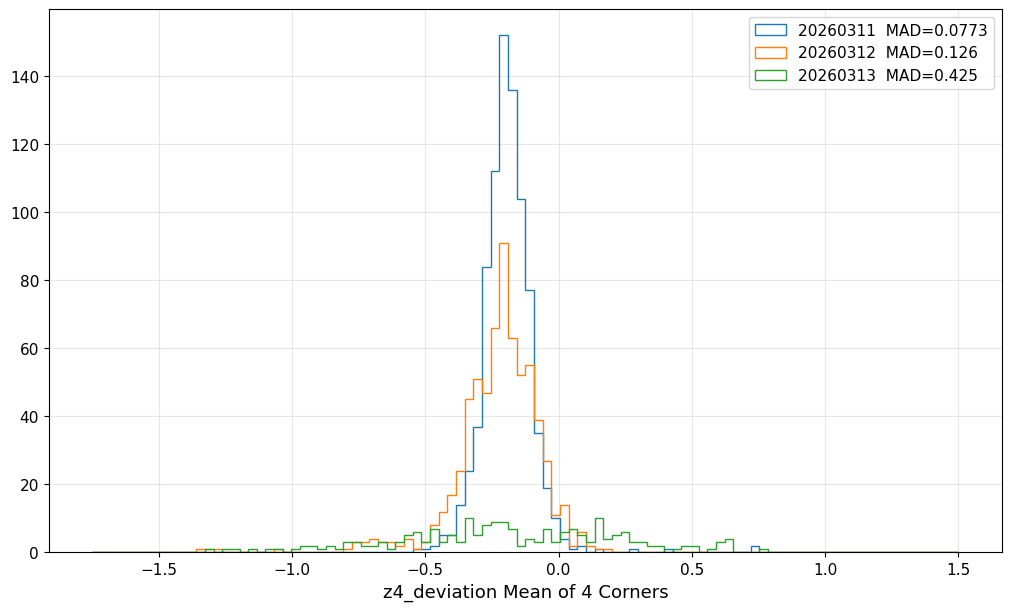

In [11]:
f, ax = plt.subplots(1, 1)
for day_obs in day_obs_list:
    iZ = 4 - 4
    val = tables[day_obs]['zk_deviation_mean'].dropna().apply(lambda x: x[iZ])
    mad = mad_std(val)
    n, bins, patches = ax.hist(val, bins=100, label=f"{day_obs}  MAD={mad:.3g}", histtype='step', range=(-1.75, 1.5))
    ax.set_xlabel('z4_deviation Mean of 4 Corners')
ax.legend()

/scratch/aroodman/tmp/ipykernel_37017/3108528397.py:13: UserWarning: The figure layout has changed to tight
  f.tight_layout()


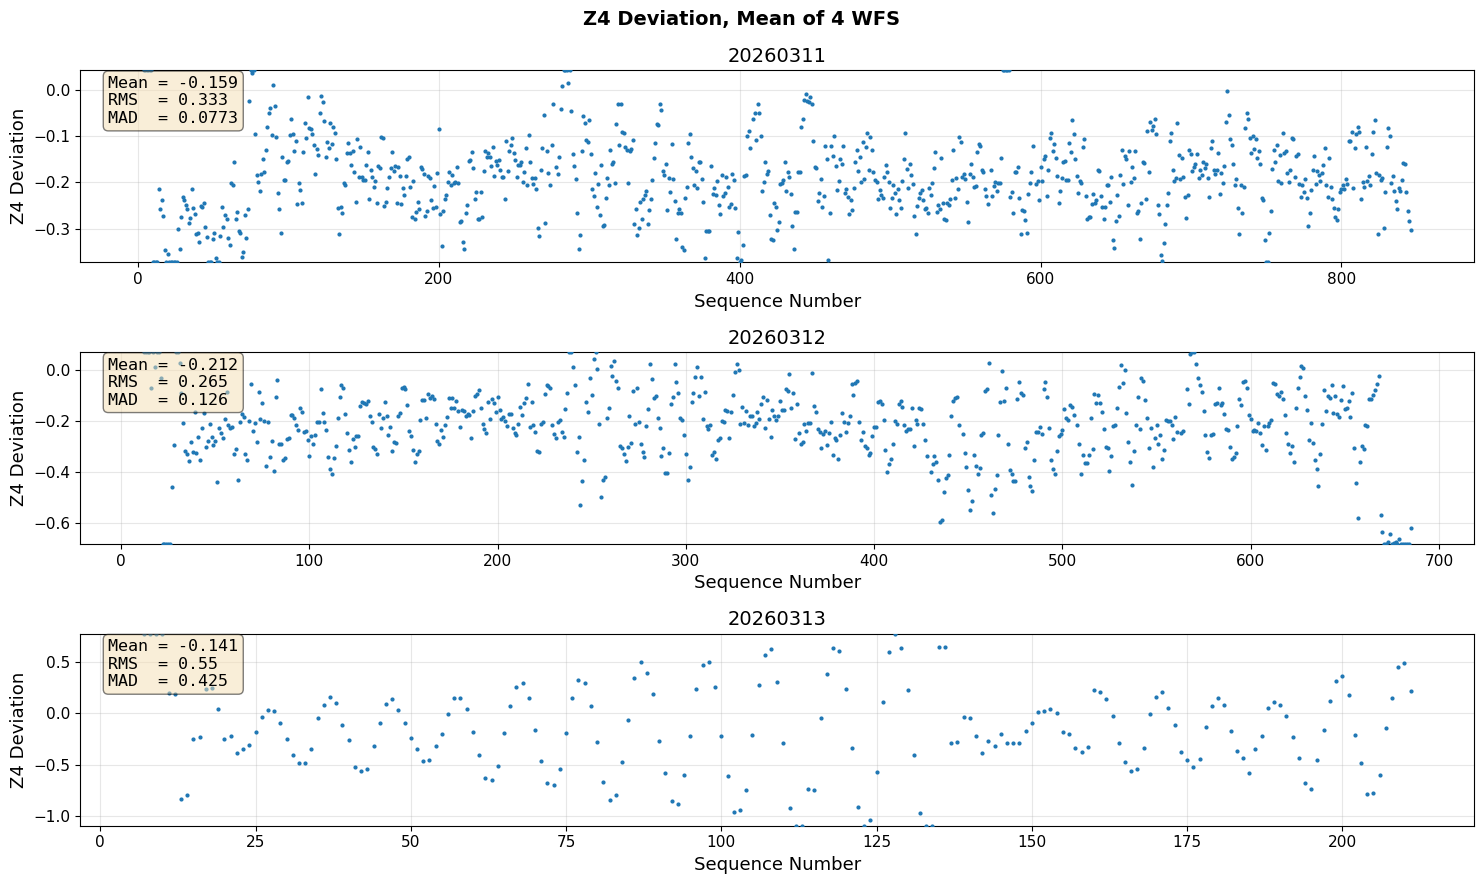

In [12]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    iZ = 4 - 4
    val = tables[day_obs]['zk_deviation_mean'].apply(
        lambda x: x[iZ] if hasattr(x, '__iter__') else float('nan')
    )
    clipped_scatter(ax[i], tables[day_obs]['seq'], val, s=4)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('Z4 Deviation')

f.suptitle('Z4 Deviation, Mean of 4 WFS', fontsize=14, fontweight='bold')
f.tight_layout()

/scratch/aroodman/tmp/ipykernel_37017/667620693.py:13: UserWarning: The figure layout has changed to tight
  f.tight_layout()


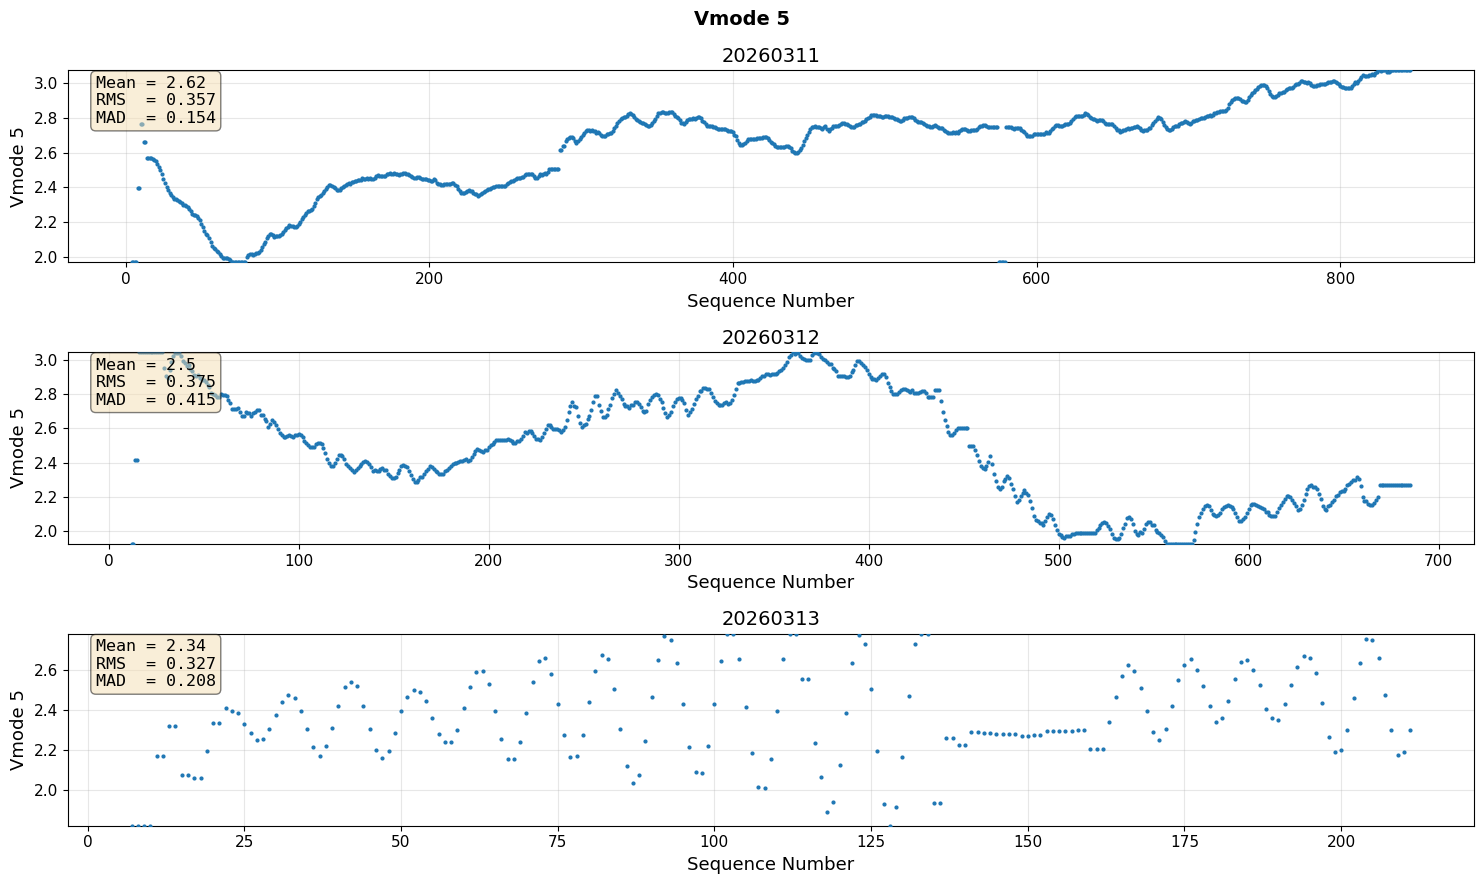

In [13]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    iV = 5 - 1
    val = tables[day_obs]['vmodes'].apply(
        lambda x: x[iV] if hasattr(x, '__iter__') else float('nan')
    )
    clipped_scatter(ax[i], tables[day_obs]['seq'], val, s=4,pct_low=2.,pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('Vmode 5')

f.suptitle('Vmode 5', fontsize=14, fontweight='bold')
f.tight_layout()

/scratch/aroodman/tmp/ipykernel_37017/947274907.py:13: UserWarning: The figure layout has changed to tight
  f.tight_layout()


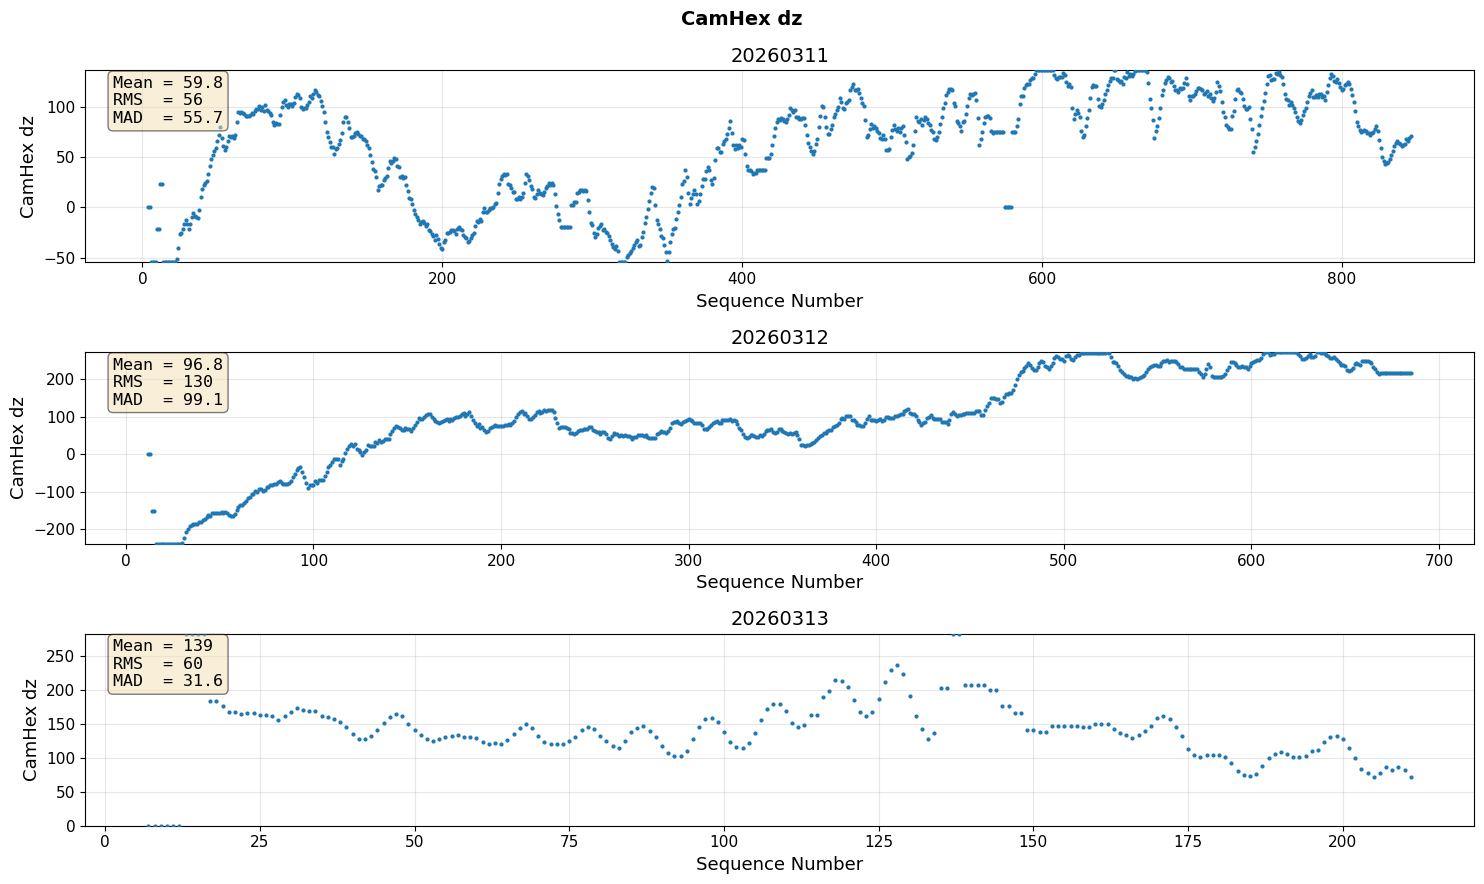

In [14]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    iDof = 5
    val = tables[day_obs]['dof_state'].apply(
        lambda x: x[iDof] if hasattr(x, '__iter__') else float('nan')
    )
    clipped_scatter(ax[i], tables[day_obs]['seq'], val, s=4,pct_low=2.,pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('CamHex dz')

f.suptitle('CamHex dz', fontsize=14, fontweight='bold')
f.tight_layout()

### Degrees of Freedom Plots

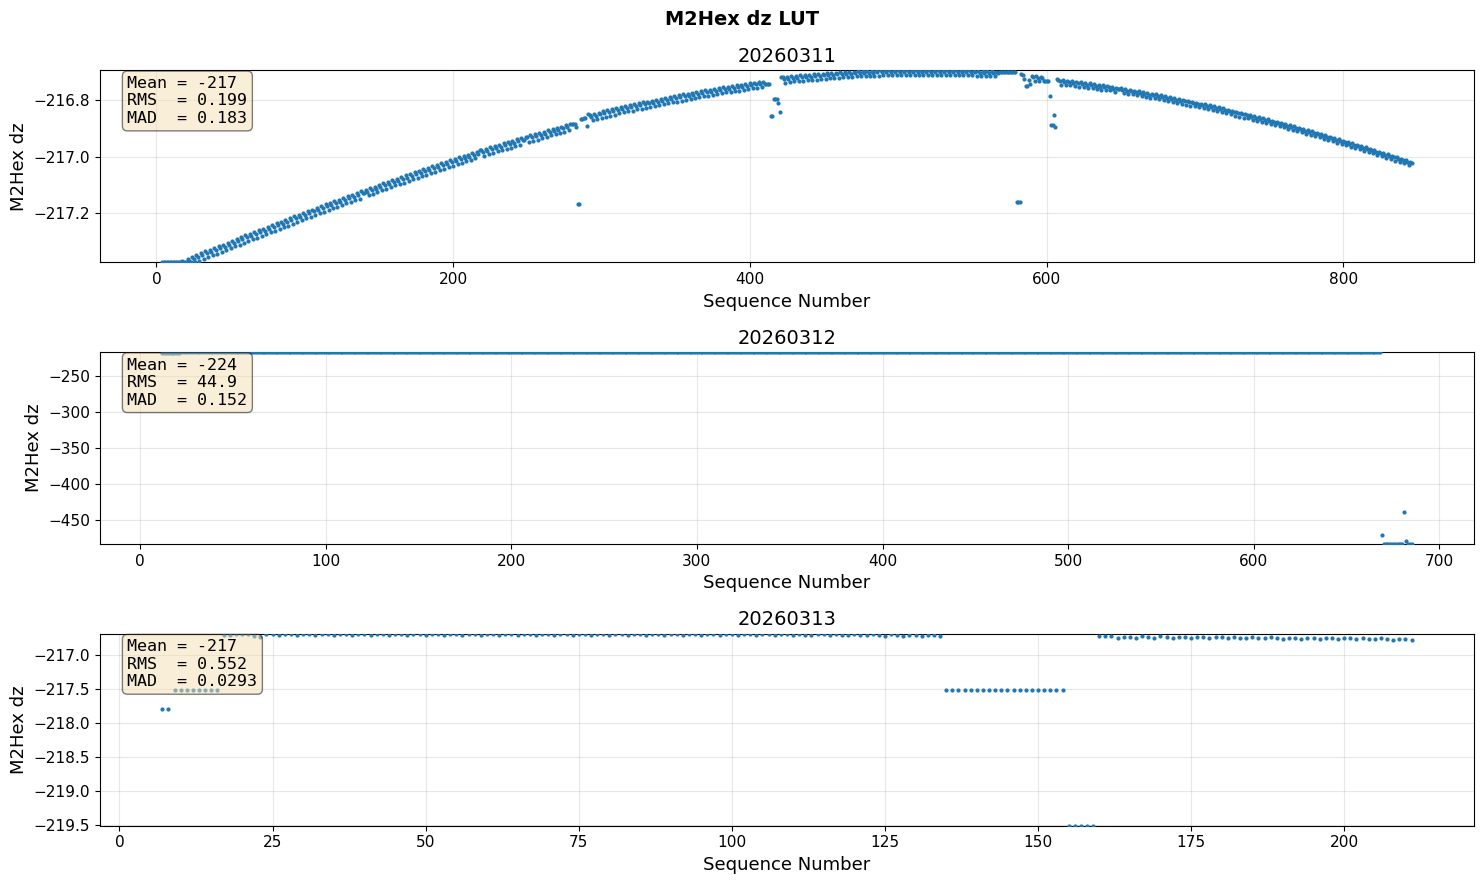

In [15]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    t = tables[day_obs]  # <-- make sure t is set inside the loop
    clipped_scatter(ax[i], t['seq'], get_lut(t, 'M2_dz'), s=4, pct_low=2., pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('M2Hex dz')

f.suptitle('M2Hex dz LUT', fontsize=14, fontweight='bold')
f.set_layout_engine('tight')

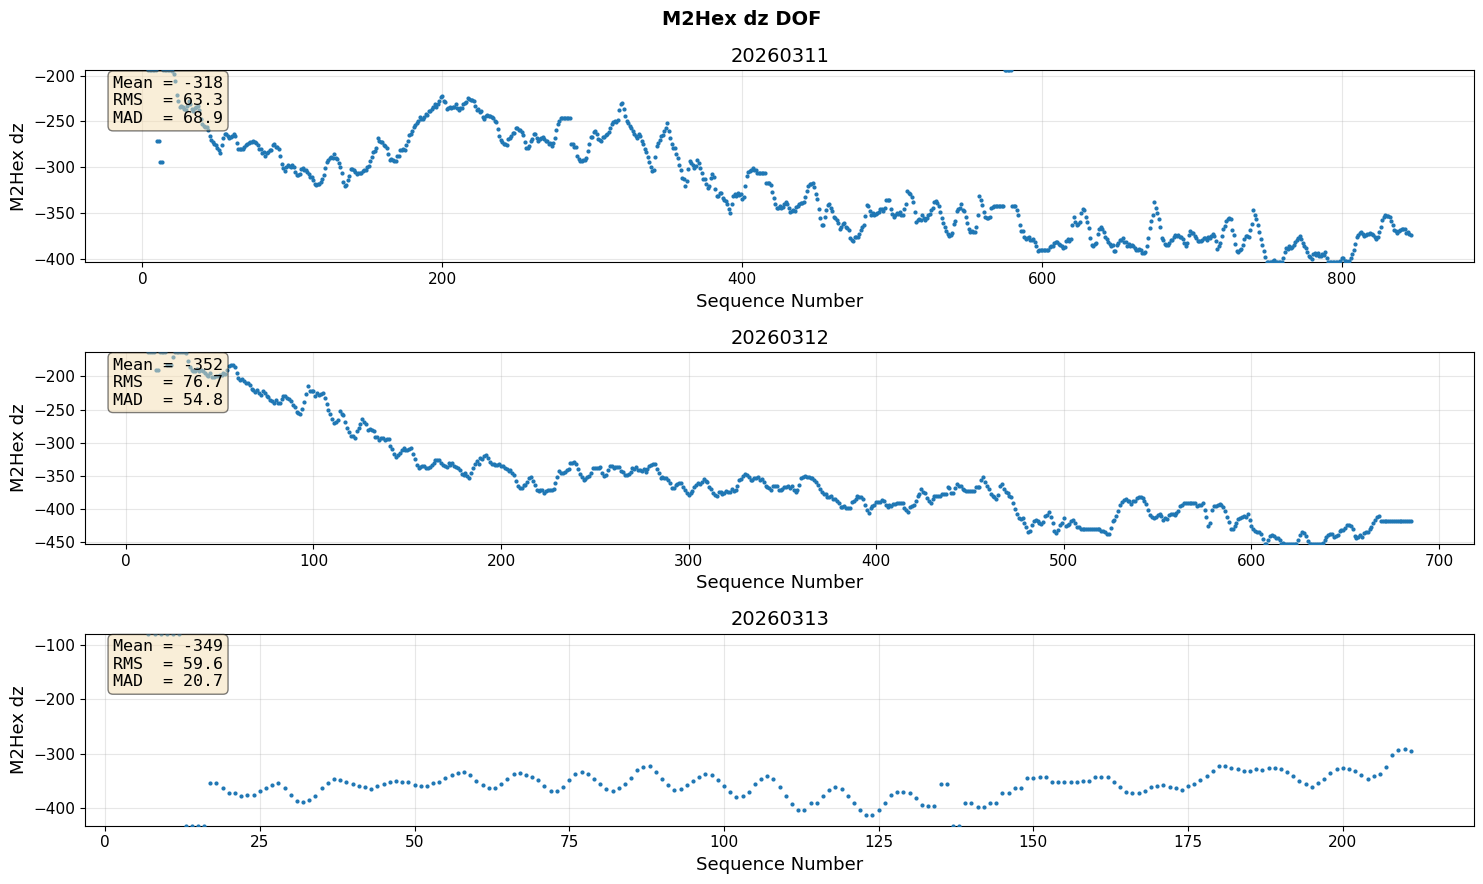

In [16]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    t = tables[day_obs]  # <-- make sure t is set inside the loop
    clipped_scatter(ax[i], t['seq'], get_dof(t, 'M2_dz'), s=4, pct_low=2., pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('M2Hex dz')

f.suptitle('M2Hex dz DOF', fontsize=14, fontweight='bold')
f.set_layout_engine('tight')

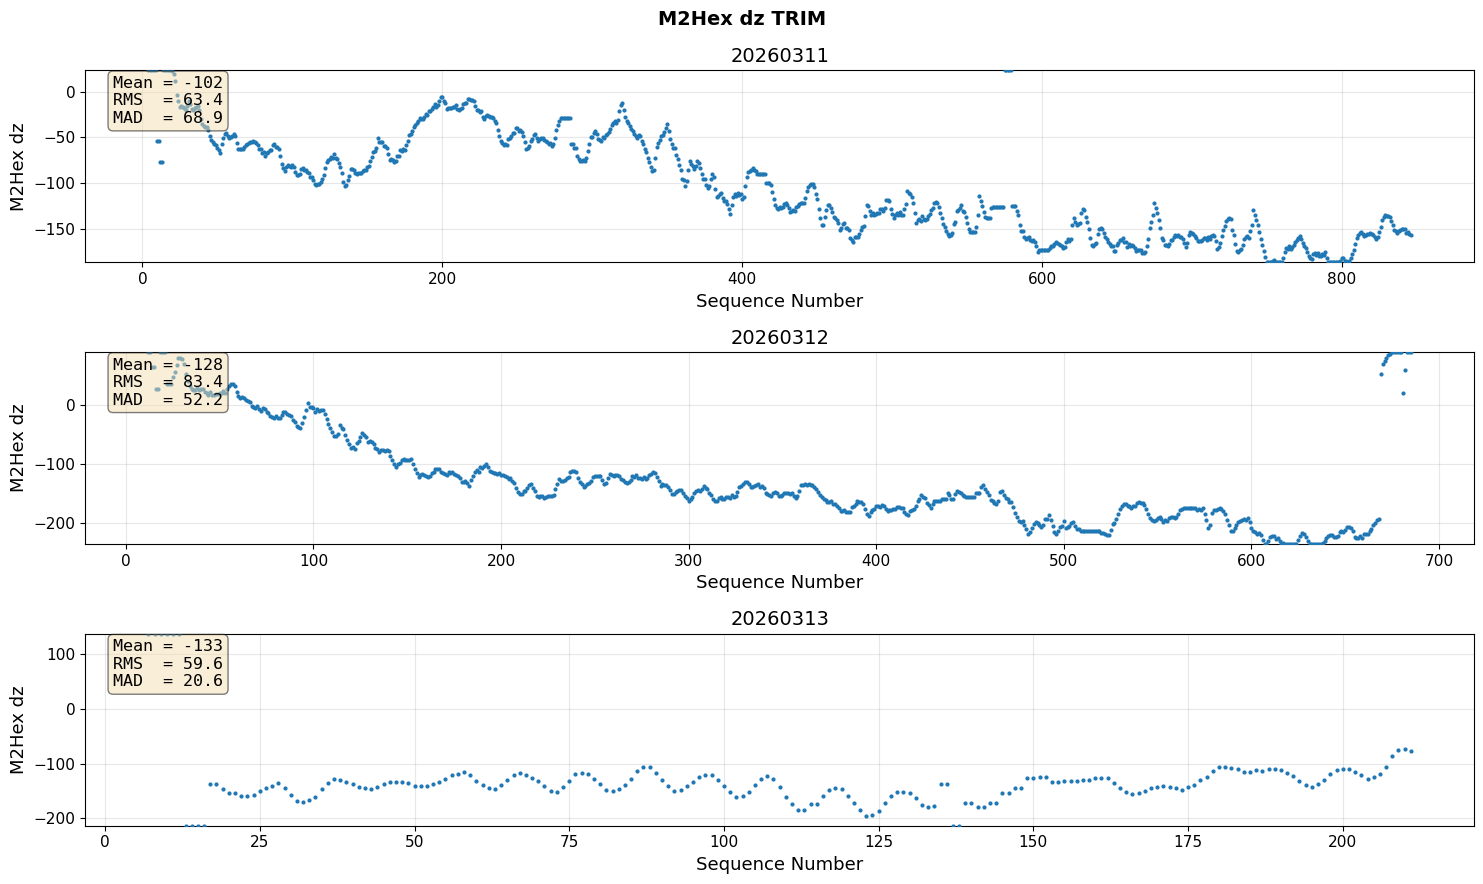

In [17]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    t = tables[day_obs]  # <-- make sure t is set inside the loop
    clipped_scatter(ax[i], t['seq'], get_trim(t, 'M2_dz'), s=4, pct_low=2., pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('M2Hex dz')

f.suptitle('M2Hex dz TRIM', fontsize=14, fontweight='bold')
f.set_layout_engine('tight')

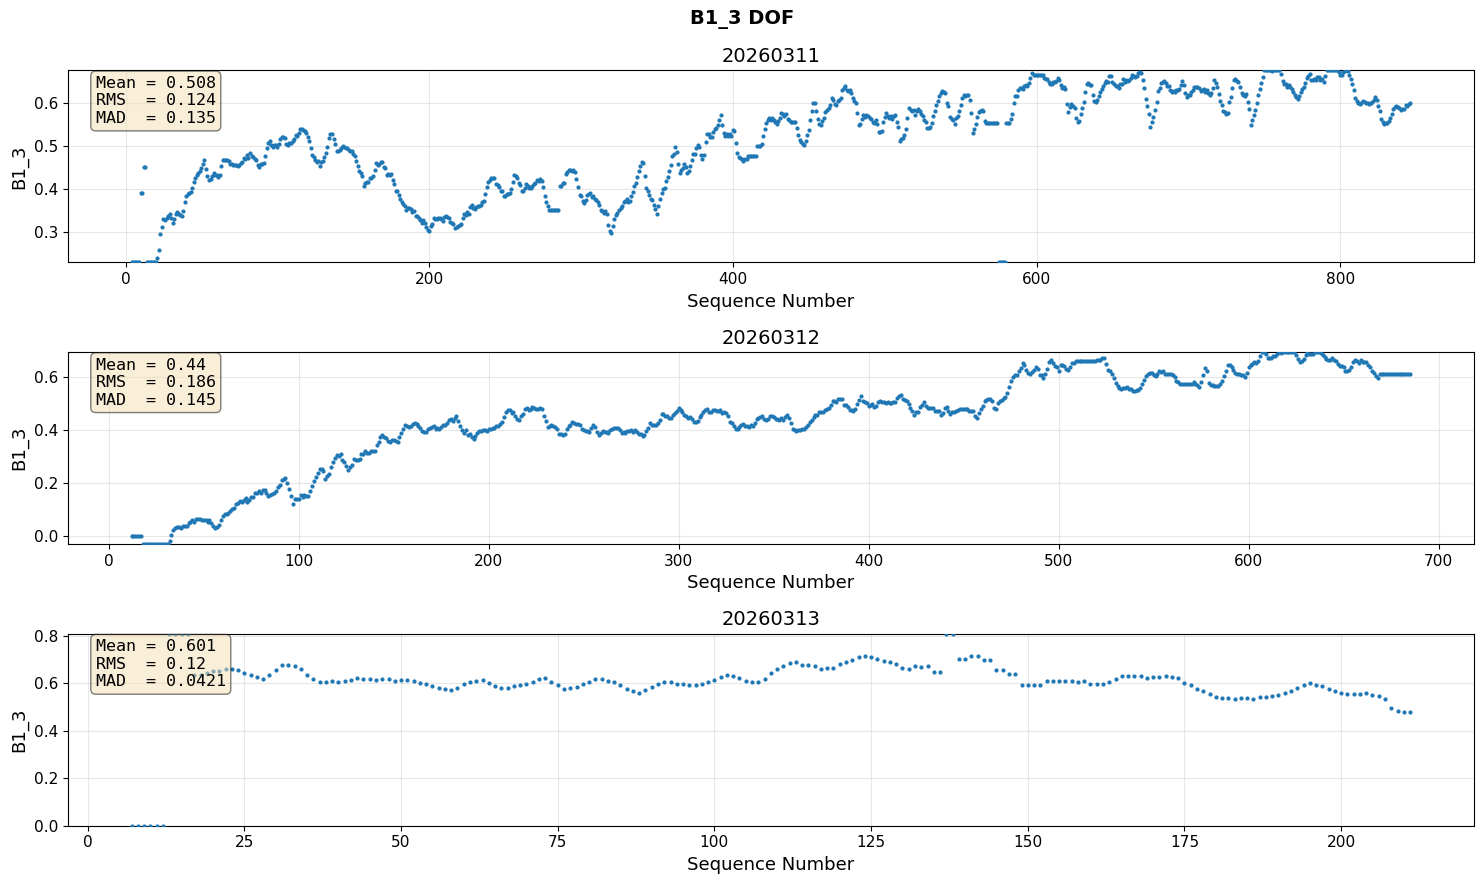

In [18]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    t = tables[day_obs]  # <-- make sure t is set inside the loop
    clipped_scatter(ax[i], t['seq'], get_dof(t, 'B1_3'), s=4, pct_low=2., pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('B1_3')

f.suptitle('B1_3 DOF', fontsize=14, fontweight='bold')
f.set_layout_engine('tight')

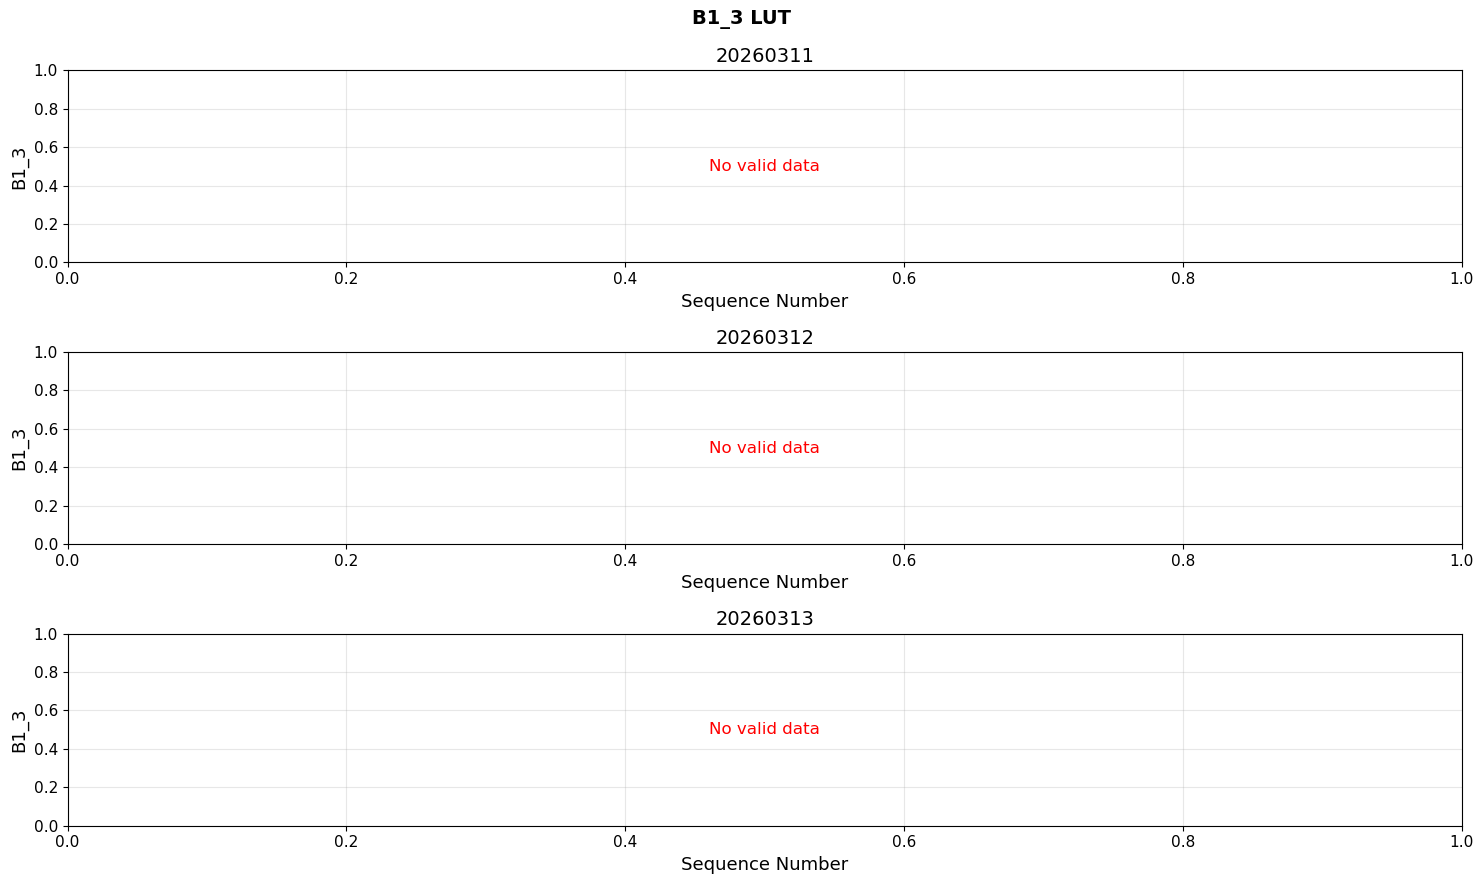

In [19]:
f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    t = tables[day_obs]  # <-- make sure t is set inside the loop
    clipped_scatter(ax[i], t['seq'], get_lut(t, 'B1_3'), s=4, pct_low=2., pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Sequence Number')
    ax[i].set_ylabel('B1_3')

f.suptitle('B1_3 LUT', fontsize=14, fontweight='bold')
f.set_layout_engine('tight')

/scratch/aroodman/tmp/ipykernel_37017/450899446.py:29: UserWarning: The figure layout has changed to tight
  f.tight_layout()


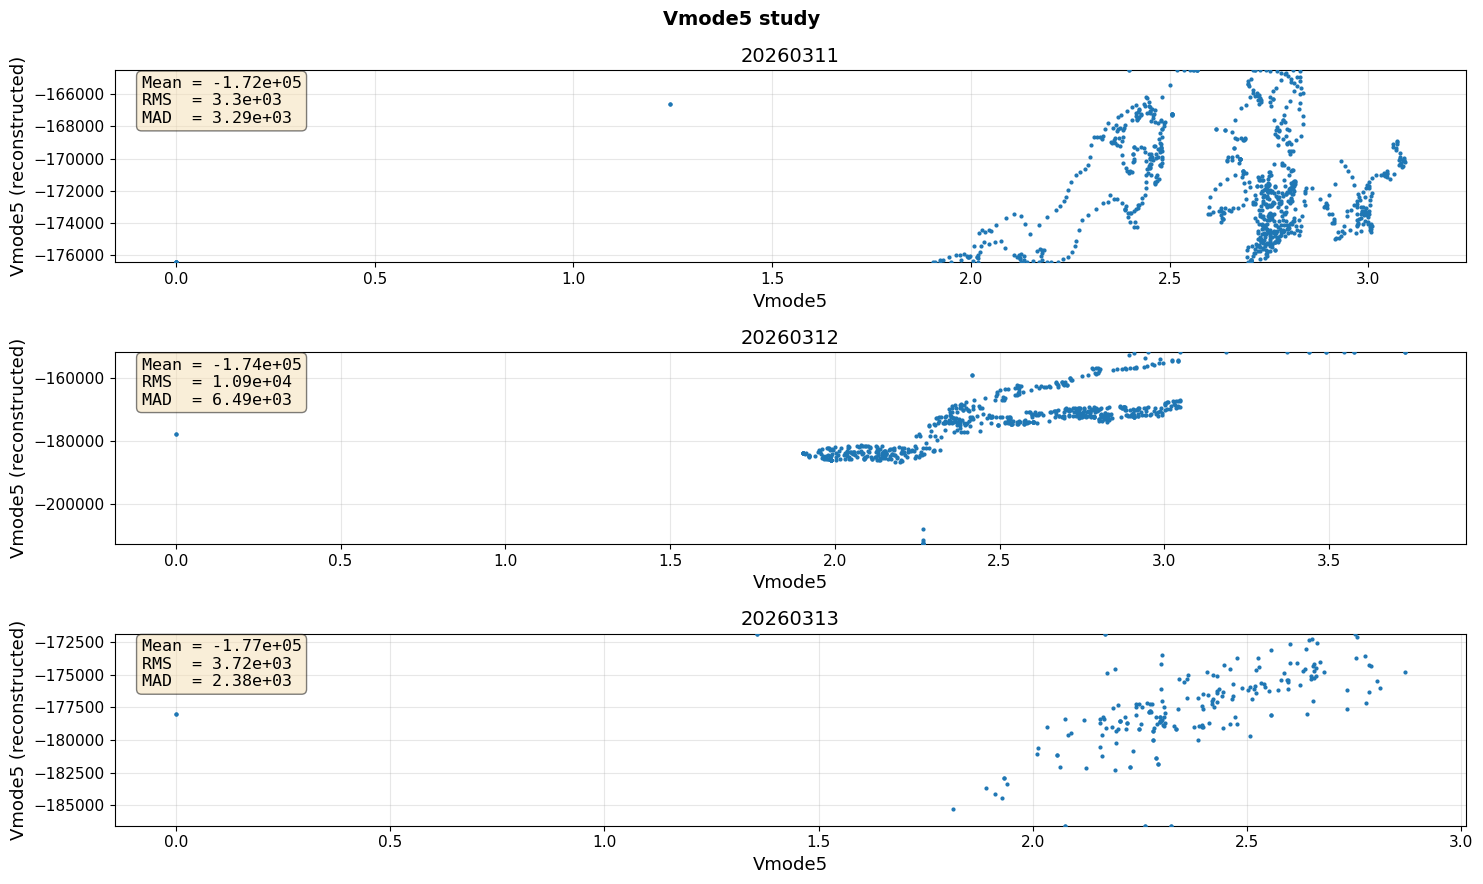

In [43]:
# test Vmode =  -88.0325*Cam_dz  -36.2581*M2_dz  +0.0065*B1_3  +0.0051*B2_5

f, ax = plt.subplots(3, 1, figsize=(15, 9))
for i, day_obs in enumerate(day_obs_list):
    t = tables[day_obs]

    # Reconstruct Vmode5 from dof_state using the formula
    vmode5_reconB = (  -88.0325 * get_trim(t, 'Cam_dz')
                      -36.2581 * get_trim(t, 'M2_dz')
                      +  0.0065 * get_dof(t, 'B1_3')
                      +  0.0051 * get_dof(t, 'B2_5') )

    vmode5_recon = (  -0.843 * get_dof(t, 'Cam_dz')
                      -0.531 * get_dof(t, 'M2_dz')
                      +0.068 * get_dof(t, 'B1_3')
                      +0.061 * get_dof(t, 'B2_5') )

    iV = 5 - 1
    vmode5 = tables[day_obs]['vmodes'].apply(
        lambda x: x[iV] if hasattr(x, '__iter__') else float('nan')
    )
    
    clipped_scatter(ax[i], vmode5, vmode5_reconB, s=4, pct_low=2., pct_high=98.)
    ax[i].set_title(str(day_obs))
    ax[i].set_xlabel('Vmode5')
    ax[i].set_ylabel('Vmode5 (reconstructed)')

f.suptitle('Vmode5 study', fontsize=14, fontweight='bold')
f.tight_layout()

In [21]:
for day_obs in day_obs_list:
    print(day_obs, tables[day_obs]['lut_state'].notna().sum())

20260311 843
20260312 674
20260313 205


In [22]:
# Check the first table
t = tables[day_obs_list[0]]

# What does dof_state look like?
print(t['dof_state'].dtype)
print(t['dof_state'].head(5))

# How many non-null entries?
print('non-null:', t['dof_state'].notna().sum())

# What does one entry look like?
first_valid = t['dof_state'].dropna().iloc[0]
print('type:', type(first_valid))
print('value:', first_valid)
print('len:', len(first_valid) if hasattr(first_valid, '__iter__') else 'scalar')

object
seq
4    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
5    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
6    [-45.46758147187874, -9.699514617447722e-07, 1...
7    [-45.46758147187874, -9.699514617447722e-07, 1...
8    [-87.63878459291107, -2.0578762076456792e-06, ...
Name: dof_state, dtype: object
non-null: 843
type: <class 'numpy.ndarray'>
value: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
len: 50
